<a href="https://colab.research.google.com/github/pratikmojumder/Bar_Diagram/blob/main/Bar_Diagram.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

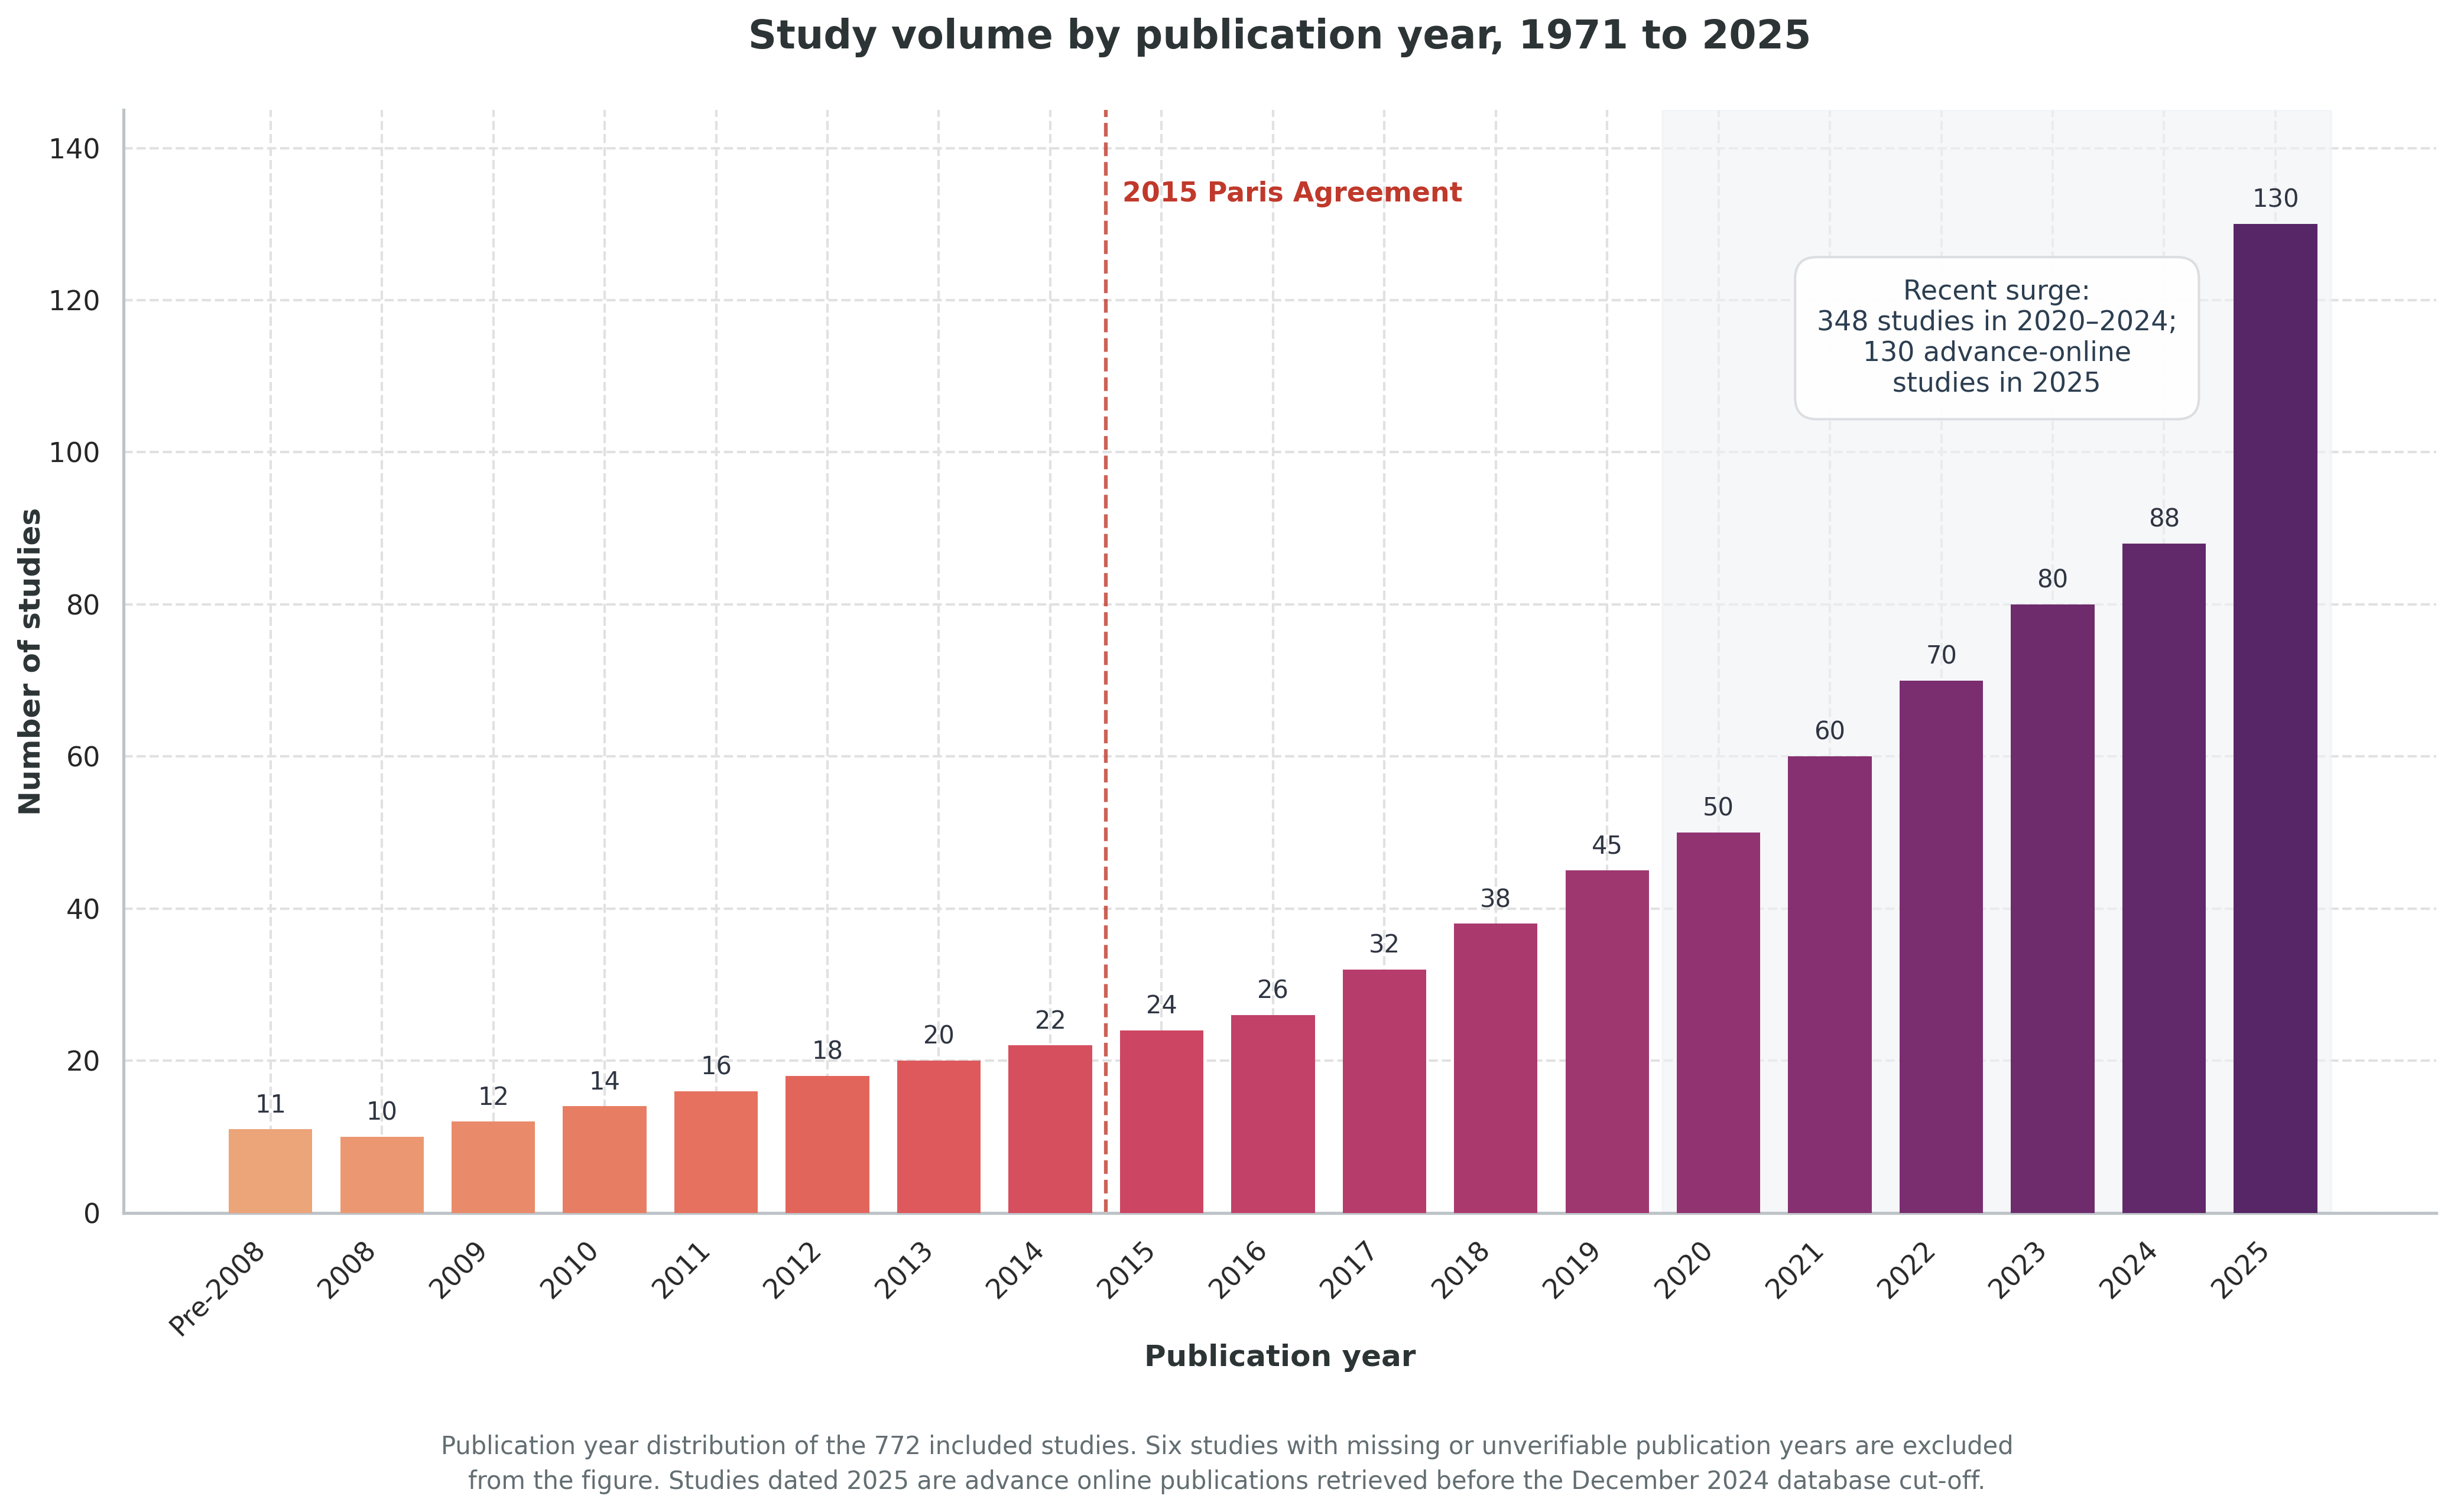

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Data Definitions
years = ['Pre-2008', '2008', '2009', '2010', '2011', '2012', '2013', '2014',
         '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022',
         '2023', '2024', '2025']
studies = [11, 10, 12, 14, 16, 18, 20, 22, 24, 26, 32, 38, 45, 50, 60, 70, 80, 88, 130]

# 2. Styling and Configuration
# Use seaborn to set a clean, modern grid
sns.set_theme(style="whitegrid", rc={"grid.color": "#e1e1e1", "grid.linestyle": "--"})
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans'] # Standard journal fonts

# Create figure with high DPI for Q1/Q2 journal publication quality
fig, ax = plt.subplots(figsize=(14, 8), dpi=300)

# Generate a color palette transitioning from cool (early years) to warm (recent surge)
# The flare palette is perceptually uniform and prints well
colors = sns.color_palette("flare", n_colors=len(years))

# 3. Plotting the Bars
bars = ax.bar(years, studies, color=colors, edgecolor='none', width=0.75, zorder=3)

# Add data labels exactly above each bar
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 1.5,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=10, color='#2f3542', fontweight='500')

# 4. Annotations and Highlights
# The 2015 Paris Agreement Line (Placed right before 2015, which is index 8)
ax.axvline(x=7.5, color='#c0392b', linestyle='--', linewidth=1.5, alpha=0.8, zorder=2)
ax.text(7.65, 133, '2015 Paris Agreement', color='#c0392b', fontsize=11, fontweight='bold')

# Highlight the recent surge (From 2020 to 2025 -> indices 13 to 18)
# We extend slightly past the indices to cover the full width of the bars
ax.axvspan(12.5, 18.5, color='#f1f2f6', alpha=0.6, zorder=1)

# Surge Information Box
box_text = "Recent surge:\n348 studies in 2020–2024;\n130 advance-online\nstudies in 2025"
ax.text(15.5, 115, box_text, ha='center', va='center', fontsize=11, color='#2c3e50',
        bbox=dict(facecolor='white', edgecolor='#dcdde1', boxstyle='round,pad=0.8', alpha=0.95))

# 5. Axes Formatting
ax.set_title("Study volume by publication year, 1971 to 2025",
             fontsize=16, fontweight='bold', color='#2d3436', pad=25)
# Decreased labelpad values to move labels closer to axes
ax.set_ylabel("Number of studies", fontsize=12, color='#2d3436', fontweight='bold', labelpad=1)
ax.set_xlabel("Publication year", fontsize=12, color='#2d3436', fontweight='bold', labelpad=1)

# Tweak limits and ticks
ax.set_ylim(0, 145)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)

# Clean up spines (borders)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#bdc3c7')
ax.spines['bottom'].set_color('#bdc3c7')

# 6. Footer Caption
footer_text = (
    "Publication year distribution of the 772 included studies. Six studies with missing or "
    "unverifiable publication years are excluded\nfrom the figure. Studies dated 2025 are "
    "advance online publications retrieved before the December 2024 database cut-off."
)
plt.figtext(0.5, -0.06, footer_text, ha="center", fontsize=10, color="#636e72", linespacing=1.5)

# Adjust layout to prevent clipping of labels and footer
plt.tight_layout()

# Save the figure as a high-res PNG and PDF
plt.savefig('study_volume_modern.png', bbox_inches='tight', pad_inches=1, dpi=300)
plt.savefig('study_volume_modern.pdf', bbox_inches='tight', pad_inches=1)

# Display the plot
plt.show()